# KModes Modeling: Cleaning Clusters for Workability
This notebook will load, explore, and clean the KModes cluster work from the first notebook. The final product will be a table in my custom dataset that will join into fact_claims for predictive modeling.

In [1]:
%%bigquery diag_w_clusters
select
    dk.claim_diagnosis_key
  , cdw.clm_id
  , dk.diagnosis_code_type
  , dk.diagnosis_name
  , dk.external_flag
  , dk.clusters
from `spatial-earth-449020-m3.lexie_custom_datasets.diagnosis_kmodes` dk
left join `spatial-earth-449020-m3.capstone_data_model.claim_diagnosis_walk` cdw
  on dk.claim_diagnosis_key = cdw.claim_diagnosis_key

Query is running:   0%|          |

Downloading:   0%|          |

In [2]:
diag_w_clusters.head()

,claim_diagnosis_key,clm_id,diagnosis_code_type,diagnosis_name,external_flag,clusters
0,b'P\xfcb\x1e\x03\xa6\xe7\x8f\xe3\x17\x9d{\xda\...,-10000931007255,admitting,Convulsions of newborn,False,0
1,"b'\xe7\xd0\x0f\xcf\xcf\x15\x19\xdc""7\x9f\x86\r...",-10000930327156,admitting,"Encntr for suprvsn of normal first pregnancy, ...",False,0
2,"b'=\x96O#\xbd\x19\xba?,\xdd\xb0\xea\x14P\x82\x...",-10000930065611,admitting,Presence of aortocoronary bypass graft,False,0
3,"b""\x066\xdf$zH\xdd\xb1\xd0\x0c>\xdc\xf3\x9ff\x...",-10000930475946,admitting,Presence of aortocoronary bypass graft,False,0
4,b'\x0f\xd7\x8c\x1d\x0b\xaa\xdc\x85\xe1\xc3LuG\...,-10000931151998,admitting,"Underdosing of diagnostic agents, sequela",False,9


<Axes: xlabel='clusters', ylabel='counts'>

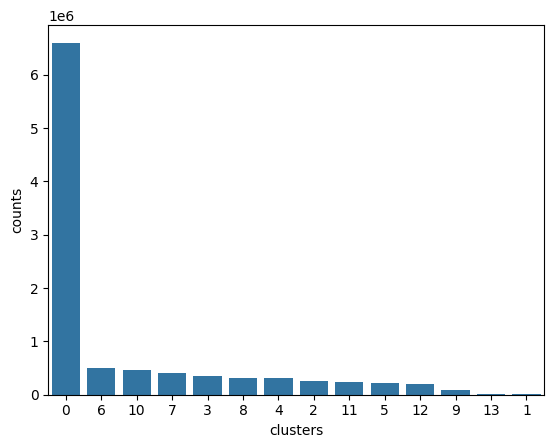

In [3]:
import seaborn as sns

cluster_counts = diag_w_clusters.groupby('clusters')['clusters'].count().reset_index(name='counts')
sns.barplot(x='clusters', y="counts", data=cluster_counts,order=cluster_counts.sort_values('counts',ascending=False)['clusters'])


## Wordclouds for Clustering
I'm going to make wordclouds for the 14 clusters to give them a human-readable name; this will let me transform the clusters into understandable dummy fields. I'm starting with smaller clusters to test the code and its utility, then will do some of the meatier clusters.

In [4]:
pip install wordcloud

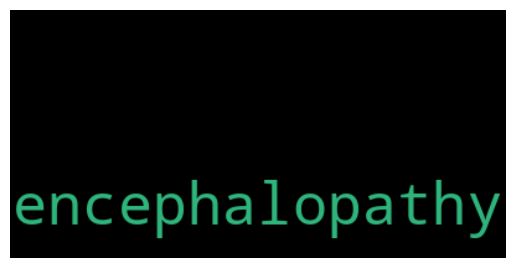

In [5]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

cluster_1 = diag_w_clusters[diag_w_clusters['clusters']==1]

wordcloud_1 = WordCloud().generate(' '.join(cluster_1['diagnosis_name']))

plt.imshow(wordcloud_1, interpolation='bilinear')
plt.axis("off")
plt.show()


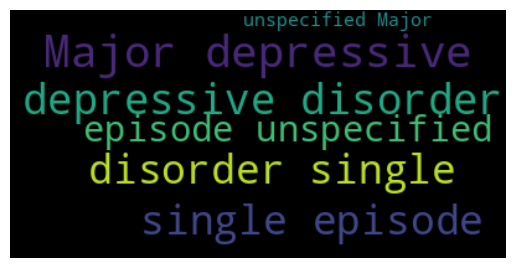

In [7]:
cluster_13 = diag_w_clusters[diag_w_clusters['clusters']==13]

wordcloud_13 = WordCloud().generate(' '.join(cluster_13['diagnosis_name']))

plt.imshow(wordcloud_13, interpolation='bilinear')
plt.axis("off")
plt.show()

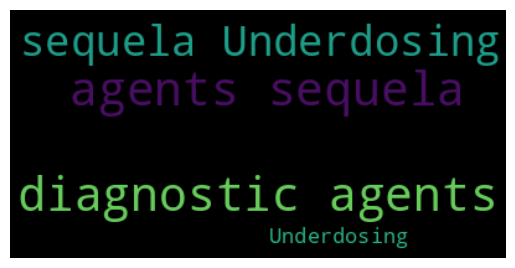

In [8]:
cluster_9 = diag_w_clusters[diag_w_clusters['clusters']==9]

wordcloud_9 = WordCloud().generate(' '.join(cluster_9['diagnosis_name']))

plt.imshow(wordcloud_9, interpolation='bilinear')
plt.axis("off")
plt.show()

Sequala is a medical term for prior complications/diagnoses impacting this diagnosis.

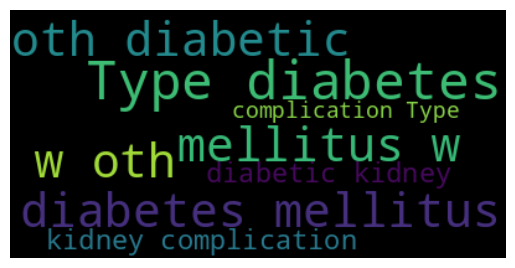

In [9]:
cluster_12 = diag_w_clusters[diag_w_clusters['clusters']==12]

wordcloud_12 = WordCloud().generate(' '.join(cluster_12['diagnosis_name']))

plt.imshow(wordcloud_12, interpolation='bilinear')
plt.axis("off")
plt.show()

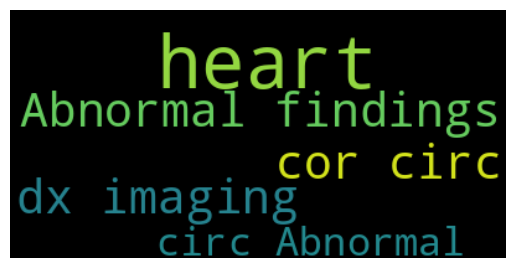

In [10]:
cluster_11 = diag_w_clusters[diag_w_clusters['clusters']==11]

wordcloud_11 = WordCloud().generate(' '.join(cluster_11['diagnosis_name']))

plt.imshow(wordcloud_11, interpolation='bilinear')
plt.axis("off")
plt.show()

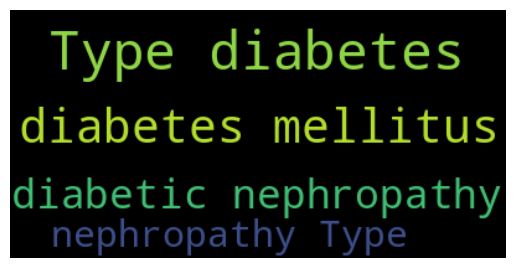

In [12]:
cluster_10 = diag_w_clusters[diag_w_clusters['clusters']==10]

wordcloud_10 = WordCloud().generate(' '.join(cluster_10['diagnosis_name']))

plt.imshow(wordcloud_10, interpolation='bilinear')
plt.axis("off")
plt.show()

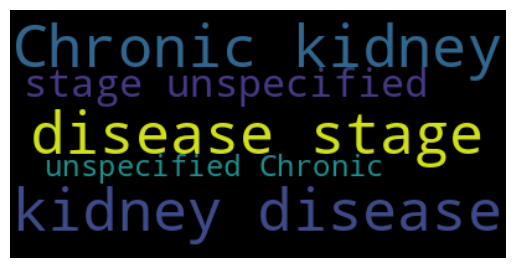

In [13]:
cluster_8 = diag_w_clusters[diag_w_clusters['clusters']==8]

wordcloud_8 = WordCloud().generate(' '.join(cluster_8['diagnosis_name']))

plt.imshow(wordcloud_8, interpolation='bilinear')
plt.axis("off")
plt.show()

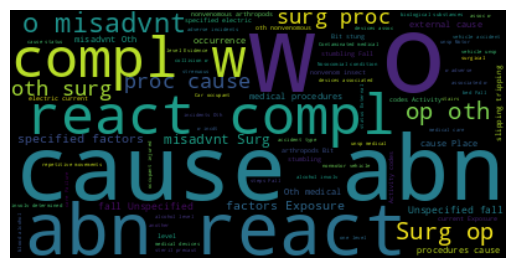

In [14]:
cluster_7 = diag_w_clusters[diag_w_clusters['clusters']==7]

wordcloud_7 = WordCloud().generate(' '.join(cluster_7['diagnosis_name']))

plt.imshow(wordcloud_7, interpolation='bilinear')
plt.axis("off")
plt.show()

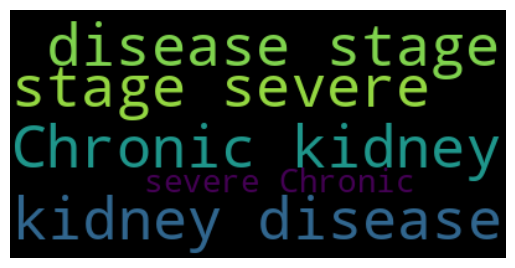

In [15]:
cluster_6 = diag_w_clusters[diag_w_clusters['clusters']==6]

wordcloud_6 = WordCloud().generate(' '.join(cluster_6['diagnosis_name']))

plt.imshow(wordcloud_6, interpolation='bilinear')
plt.axis("off")
plt.show()

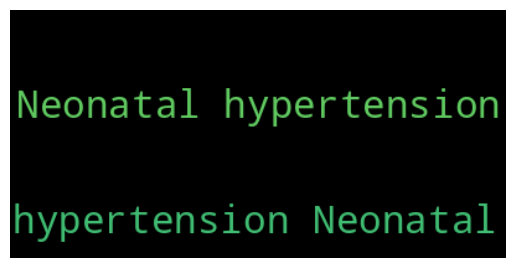

In [16]:
cluster_5 = diag_w_clusters[diag_w_clusters['clusters']==5]

wordcloud_5 = WordCloud().generate(' '.join(cluster_5['diagnosis_name']))

plt.imshow(wordcloud_5, interpolation='bilinear')
plt.axis("off")
plt.show()

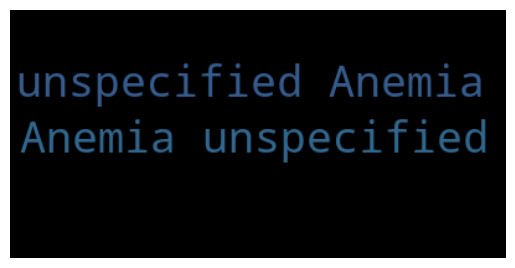

In [17]:
cluster_4 = diag_w_clusters[diag_w_clusters['clusters']==4]

wordcloud_4 = WordCloud().generate(' '.join(cluster_4['diagnosis_name']))

plt.imshow(wordcloud_4, interpolation='bilinear')
plt.axis("off")
plt.show()

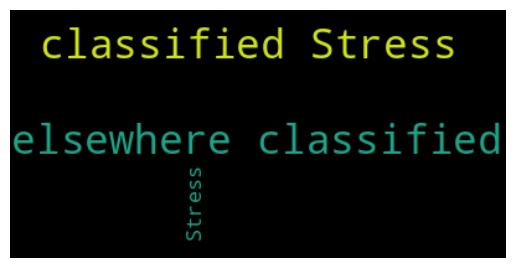

In [18]:
cluster_3 = diag_w_clusters[diag_w_clusters['clusters']==3]

wordcloud_3 = WordCloud().generate(' '.join(cluster_3['diagnosis_name']))

plt.imshow(wordcloud_3, interpolation='bilinear')
plt.axis("off")
plt.show()

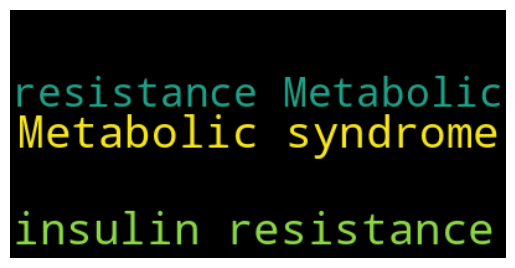

In [19]:
cluster_2 = diag_w_clusters[diag_w_clusters['clusters']==2]

wordcloud_2 = WordCloud().generate(' '.join(cluster_2['diagnosis_name']))

plt.imshow(wordcloud_2, interpolation='bilinear')
plt.axis("off")
plt.show()

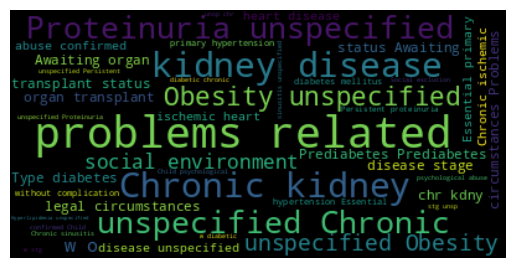

In [20]:
cluster_0 = diag_w_clusters[diag_w_clusters['clusters']==0]

wordcloud_0 = WordCloud().generate(' '.join(cluster_0['diagnosis_name']))

plt.imshow(wordcloud_0, interpolation='bilinear')
plt.axis("off")
plt.show()

Notes:

*   Cluster 0: socioeconomic, obesity, and other
*   Cluster 1: encephalopathy
*   Cluster 2: insulin resistance
*   Cluster 3: stress
*   Cluster 4: anemia
*   Cluster 5: neonatal hypertension
*   Cluster 6: severe kidney
*   Cluster 7: surgical complications
*   Cluster 8: chronic kidney
*   Cluster 9: complications general
*   Cluster 10: diabetic complications
*   Cluster 11: cardiac
*   Cluster 12: diabetes
*   Cluster 13: depression



While cluster 0 became more of a hodgepodge and there was some duplication, ultimately the clusters were able to make some sense of a LOT of variance in the diagnosis sector. I'll use the human-readable labels in the walk, then use the existence to create binaries on the claim level (i.e. represent membership in any of the 14 clusters over the claim). This will allow me to drop the three diagnosis variables at the claim level but still add depth to claims.

In [29]:
import pandas as pd

clusters_hr = { 'clusters': [0,1,2,3,4,5,6,7,8,9,10,11,12,13],
                'cluster_names': ['socioeconomic_obesity_other','encephalopathy',
                                  'insulin_resistance','stress','anemia','neonatal_hypertension',
                                  'severe_kidney','surg_complications','chronic_kidney','gen_complications',
                                  'diab_complications','cardiac','diabetes','depression']
                }

clusters_hr_df = pd.DataFrame(clusters_hr)

walk_aug = pd.merge(diag_w_clusters,clusters_hr_df,on='clusters', how='left')
walk_aug.head()

,claim_diagnosis_key,clm_id,diagnosis_code_type,diagnosis_name,external_flag,clusters,cluster_names
0,b'P\xfcb\x1e\x03\xa6\xe7\x8f\xe3\x17\x9d{\xda\...,-10000931007255,admitting,Convulsions of newborn,False,0,socioeconomic_obesity_other
1,"b'\xe7\xd0\x0f\xcf\xcf\x15\x19\xdc""7\x9f\x86\r...",-10000930327156,admitting,"Encntr for suprvsn of normal first pregnancy, ...",False,0,socioeconomic_obesity_other
2,"b'=\x96O#\xbd\x19\xba?,\xdd\xb0\xea\x14P\x82\x...",-10000930065611,admitting,Presence of aortocoronary bypass graft,False,0,socioeconomic_obesity_other
3,"b""\x066\xdf$zH\xdd\xb1\xd0\x0c>\xdc\xf3\x9ff\x...",-10000930475946,admitting,Presence of aortocoronary bypass graft,False,0,socioeconomic_obesity_other
4,b'\x0f\xd7\x8c\x1d\x0b\xaa\xdc\x85\xe1\xc3LuG\...,-10000931151998,admitting,"Underdosing of diagnostic agents, sequela",False,9,gen_complications


Now I need to aggregate this up to clm_id. I'll isolate clm_id and the human-readable cluster label, then create dummies on the label. Then I'll group by clm_id and sum the dummies. This should result in a number greater than 1 when the cluster is represented at the claim and 0 when it isn't. I'll convert those numbers greater than 1 back to a 1 to redo the binary.

In [31]:
claim_cluster_binaries = walk_aug[['clm_id','cluster_names']]
claim_cluster_binaries = pd.get_dummies(claim_cluster_binaries)

,clm_id,cluster_names_anemia,cluster_names_cardiac,cluster_names_chronic_kidney,cluster_names_depression,cluster_names_diab_complications,cluster_names_diabetes,cluster_names_encephalopathy,cluster_names_gen_complications,cluster_names_insulin_resistance,cluster_names_neonatal_hypertension,cluster_names_severe_kidney,cluster_names_socioeconomic_obesity_other,cluster_names_stress,cluster_names_surg_complications
0,-10000931007255,False,False,False,False,False,False,False,False,False,False,False,True,False,False
1,-10000930327156,False,False,False,False,False,False,False,False,False,False,False,True,False,False
2,-10000930065611,False,False,False,False,False,False,False,False,False,False,False,True,False,False
3,-10000930475946,False,False,False,False,False,False,False,False,False,False,False,True,False,False
4,-10000931151998,False,False,False,False,False,False,False,True,False,False,False,False,False,False


In [33]:
claim_cluster_grouped = claim_cluster_binaries.groupby('clm_id').sum()
claim_cluster_grouped.head()

,cluster_names_anemia,cluster_names_cardiac,cluster_names_chronic_kidney,cluster_names_depression,cluster_names_diab_complications,cluster_names_diabetes,cluster_names_encephalopathy,cluster_names_gen_complications,cluster_names_insulin_resistance,cluster_names_neonatal_hypertension,cluster_names_severe_kidney,cluster_names_socioeconomic_obesity_other,cluster_names_stress,cluster_names_surg_complications
clm_id,,,,,,,,,,,,,,
-10000931486362,0,0,0,0,1,0,0,0,1,0,0,11,0,0
-10000931486361,0,0,0,0,2,0,0,0,1,0,0,10,0,0
-10000931486360,0,0,0,0,2,1,0,0,1,0,0,9,0,0
-10000931486359,0,0,0,0,1,1,0,0,1,0,0,10,0,0
-10000931486358,0,0,1,0,0,0,0,0,1,0,1,10,0,0


In [40]:
claim_cluster_grouped.loc[claim_cluster_grouped['cluster_names_anemia'] > 1,'cluster_names_anemia'] = 1
claim_cluster_grouped.loc[claim_cluster_grouped['cluster_names_cardiac'] > 1,'cluster_names_cardiac'] = 1
claim_cluster_grouped.loc[claim_cluster_grouped['cluster_names_chronic_kidney'] > 1,'cluster_names_chronic_kidney'] = 1
claim_cluster_grouped.loc[claim_cluster_grouped['cluster_names_depression'] > 1,'cluster_names_depression'] = 1
claim_cluster_grouped.loc[claim_cluster_grouped['cluster_names_diab_complications'] > 1,'cluster_names_diab_complications'] = 1
claim_cluster_grouped.loc[claim_cluster_grouped['cluster_names_diabetes'] > 1,'cluster_names_diabetes'] = 1
claim_cluster_grouped.loc[claim_cluster_grouped['cluster_names_encephalopathy'] > 1,'cluster_names_encephalopathy'] = 1
claim_cluster_grouped.loc[claim_cluster_grouped['cluster_names_gen_complications'] > 1,'cluster_names_gen_complications'] = 1
claim_cluster_grouped.loc[claim_cluster_grouped['cluster_names_insulin_resistance'] > 1,'cluster_names_insulin_resistance'] = 1
claim_cluster_grouped.loc[claim_cluster_grouped['cluster_names_neonatal_hypertension'] > 1,'cluster_names_neonatal_hypertension'] = 1
claim_cluster_grouped.loc[claim_cluster_grouped['cluster_names_severe_kidney'] > 1,'cluster_names_severe_kidney'] = 1
claim_cluster_grouped.loc[claim_cluster_grouped['cluster_names_socioeconomic_obesity_other'] > 1,'cluster_names_socioeconomic_obesity_other'] = 1
claim_cluster_grouped.loc[claim_cluster_grouped['cluster_names_stress'] > 1,'cluster_names_stress'] = 1
claim_cluster_grouped.loc[claim_cluster_grouped['cluster_names_surg_complications'] > 1,'cluster_names_surg_complications'] = 1

claim_cluster_grouped.head()

,cluster_names_anemia,cluster_names_cardiac,cluster_names_chronic_kidney,cluster_names_depression,cluster_names_diab_complications,cluster_names_diabetes,cluster_names_encephalopathy,cluster_names_gen_complications,cluster_names_insulin_resistance,cluster_names_neonatal_hypertension,cluster_names_severe_kidney,cluster_names_socioeconomic_obesity_other,cluster_names_stress,cluster_names_surg_complications
clm_id,,,,,,,,,,,,,,
-10000931486362,0,0,0,0,1,0,0,0,1,0,0,1,0,0
-10000931486361,0,0,0,0,1,0,0,0,1,0,0,1,0,0
-10000931486360,0,0,0,0,1,1,0,0,1,0,0,1,0,0
-10000931486359,0,0,0,0,1,1,0,0,1,0,0,1,0,0
-10000931486358,0,0,1,0,0,0,0,0,1,0,1,1,0,0


Finally, will export to my schema in BigQuery so I can connect to fact_claims, finish EDA, and carry on with predictive modeling!

In [42]:
from pandas_gbq import to_gbq

project_id = 'spatial-earth-449020-m3'
table_name = 'lexie_custom_datasets.claims_with_clusters'

# Write DataFrame to BigQuery
to_gbq(claim_cluster_grouped, table_name, project_id=project_id, if_exists='replace')

100%|██████████| 1/1 [00:00<00:00, 7013.89it/s]
